Using device: cpu


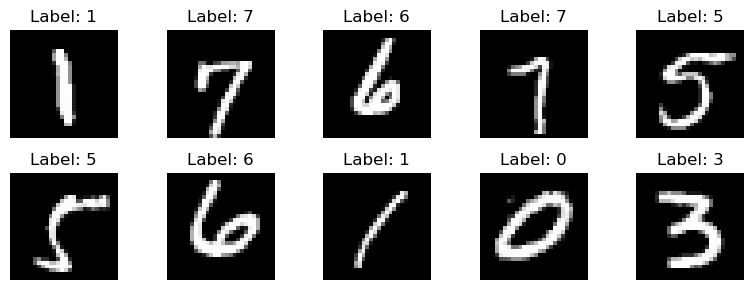

In [8]:

# CNN using MNIST handwritten digit classification

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# --------------------------------------------------
# 1. Set device
# --------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# --------------------------------------------------
# 2. Define image transformations
# --------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])


# --------------------------------------------------
# 3. Load MNIST dataset
# --------------------------------------------------

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# --------------------------------------------------
# 4. Create DataLoaders
# --------------------------------------------------

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# --------------------------------------------------
# 5. Visualize sample MNIST images
# --------------------------------------------------

images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 3))

for i in range(10):

    plt.subplot(2, 5, i + 1)
    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()




In [9]:

# --------------------------------------------------
# 6. Define CNN model
# --------------------------------------------------

class CNNModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)

        return x


model = CNNModel().to(device)

print(model)


CNNModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [13]:


# --------------------------------------------------
# 7. Define loss function and optimizer
# --------------------------------------------------

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# --------------------------------------------------
# 8. Train the CNN model
# --------------------------------------------------

num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = loss_function(
            outputs,
            labels
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = (
        correct_predictions / total_samples
    ) * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )


# --------------------------------------------------
# 9. Evaluate the CNN model
# --------------------------------------------------

model.eval()

correct_predictions = 0
total_samples = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = (
    correct_predictions / total_samples
) * 100

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)



Epoch 1/5 | Loss: 0.0338 | Training Accuracy: 98.93%
Epoch 2/5 | Loss: 0.0296 | Training Accuracy: 99.01%
Epoch 3/5 | Loss: 0.0244 | Training Accuracy: 99.21%
Epoch 4/5 | Loss: 0.0215 | Training Accuracy: 99.28%
Epoch 5/5 | Loss: 0.0182 | Training Accuracy: 99.39%
Test Accuracy: 99.07%


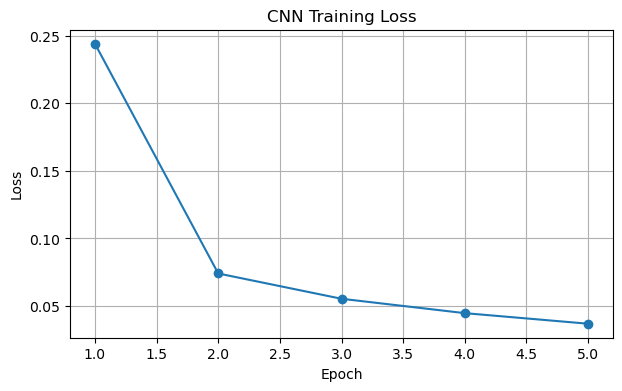

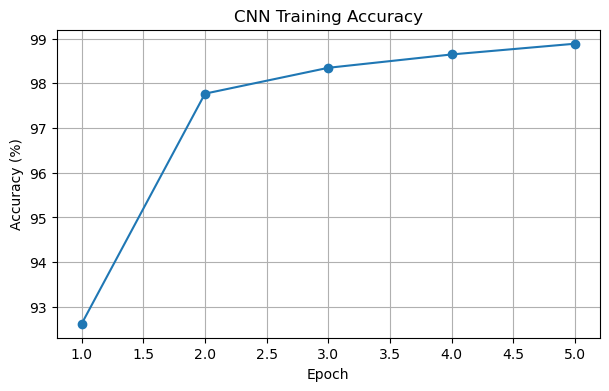

In [11]:

# --------------------------------------------------
# 10. Plot training loss and accuracy
# --------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Training Accuracy")
plt.grid(True)
plt.show()


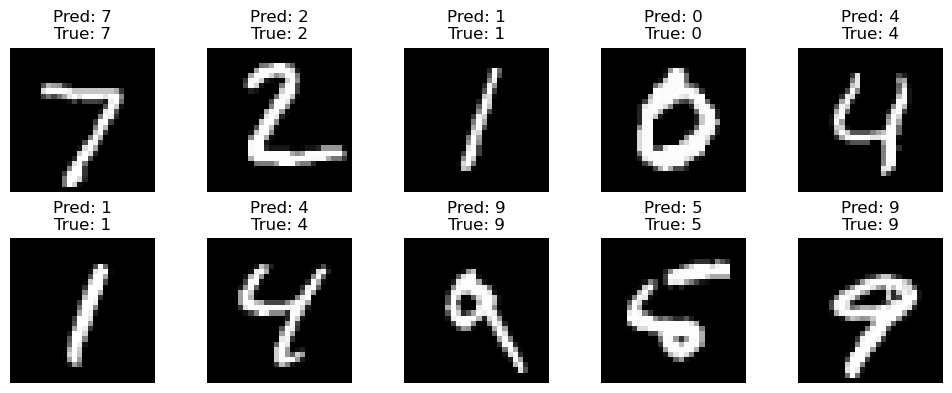

In [17]:


# --------------------------------------------------
# 11. Visualize predictions
# --------------------------------------------------

model.eval()

sample_images, sample_labels = next(iter(test_loader))

sample_images = sample_images.to(device)

with torch.no_grad():

    sample_outputs = model(sample_images)

    sample_predictions = torch.argmax(
        sample_outputs,
        dim=1
    )

sample_images = sample_images.cpu()
sample_predictions = sample_predictions.cpu()

plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        sample_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred: {sample_predictions[i].item()}\n"
        f"True: {sample_labels[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()



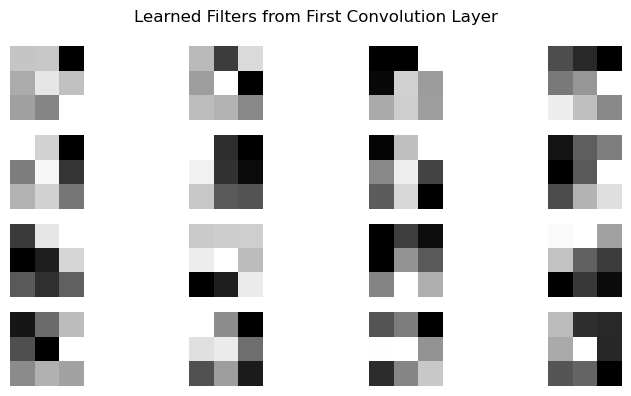

In [12]:

# --------------------------------------------------
# 12. Visualize learned filters from first Conv2D layer
# --------------------------------------------------

first_layer_weights = (
    model.conv_block_1[0]
    .weight
    .detach()
    .cpu()
)

plt.figure(figsize=(8, 4))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        first_layer_weights[i, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Learned Filters from First Convolution Layer")
plt.tight_layout()
plt.show()



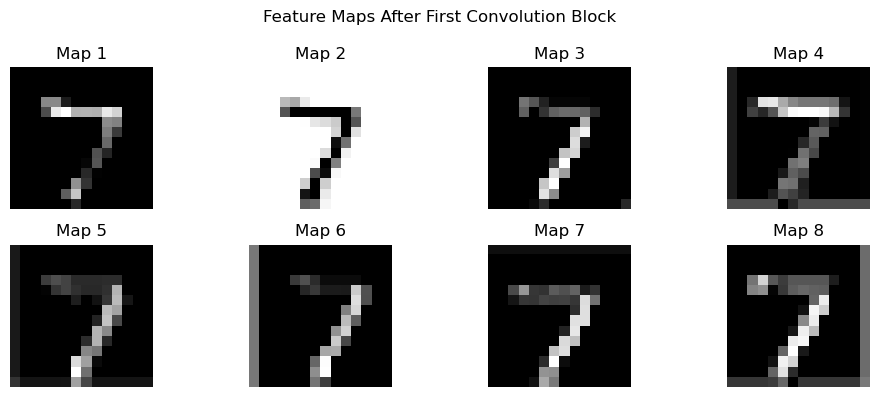

In [16]:

# --------------------------------------------------
# 13. Visualize intermediate feature maps
# --------------------------------------------------

sample_image = sample_images[0].unsqueeze(0).to(device)

with torch.no_grad():

    feature_maps = model.conv_block_1(sample_image)

feature_maps = feature_maps.cpu()

plt.figure(figsize=(10, 4))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        feature_maps[0, i],
        cmap="gray"
    )

    plt.title(f"Map {i + 1}")
    plt.axis("off")

plt.suptitle("Feature Maps After First Convolution Block")
plt.tight_layout()
plt.show()



In [15]:

# --------------------------------------------------
# 14. Save trained model
# --------------------------------------------------

torch.save(
    model.state_dict(),
    "cnn_mnist_model.pth"
)

print("Model saved as cnn_mnist_model.pth")

Model saved as cnn_mnist_model.pth
